# 02 — Entraînement de ResNet18

Ce notebook charge les données préparées dans le notebook 01, construit le modèle, explique les hyperparamètres et permet de relancer l’entraînement complet sur GPU. Les courbes affichées proviennent de l’expérience réelle sur RTX 5070.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.data import BalineseDataModule
from src.models.lightning_module import BalineseClassifier
from src.models.callbacks import build_training_callbacks

print('PyTorch :', torch.__version__)
print('CUDA :', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU :', torch.cuda.get_device_name(0))

PyTorch : 2.9.1+cu128
CUDA : True
GPU : NVIDIA GeForce RTX 5070 Laptop GPU


## 1. DataModule

Le DataModule applique des transformations aléatoires uniquement au train. Validation et test restent déterministes. La taille 128×128 accélère l’entraînement tout en conservant les formes des glyphes.

In [2]:
data = BalineseDataModule(
    data_dir=ROOT/'data/processed', backbone='resnet18', image_size=128,
    batch_size=128, num_workers=0, seed=42,
)
data.setup()
print('Classes :', data.num_classes)
print('Train / validation / test :', len(data.train_dataset), len(data.val_dataset), len(data.test_dataset))

Classes : 54
Train / validation / test : 95427 6668 6706


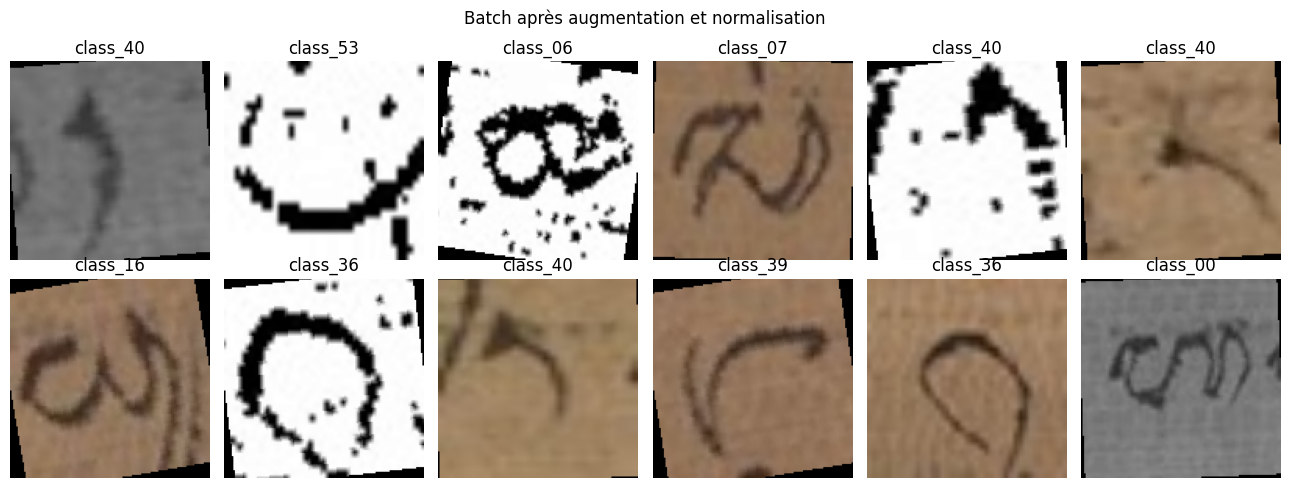

In [3]:
images, labels = next(iter(data.train_dataloader()))
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
fig, axes = plt.subplots(2, 6, figsize=(13,5))
for ax, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    ax.imshow((image*std+mean).clamp(0,1).permute(1,2,0))
    ax.set_title(data.class_names[int(label)]); ax.axis('off')
plt.suptitle('Batch après augmentation et normalisation'); plt.tight_layout(); plt.show()

## 2. Architecture

ResNet18 contient des blocs résiduels qui facilitent la propagation du gradient. Les poids ImageNet fournissent des filtres de contours et textures. La couche finale est remplacée par 54 sorties, une par classe retenue.

In [4]:
model = BalineseClassifier(num_classes=data.num_classes, backbone='resnet18', learning_rate=3e-4, pretrained=True)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model.model.fc)
print(f'Paramètres totaux : {total:,}')
print(f'Paramètres entraînables : {trainable:,}')

Linear(in_features=512, out_features=54, bias=True)
Paramètres totaux : 11,204,214
Paramètres entraînables : 11,204,214


## 3. Hyperparamètres

- Optimiseur : Adam
- Learning rate : 3×10⁻⁴
- Batch : 128
- Époques maximales : 8
- Loss : cross-entropy
- Précision : AMP FP16
- Sélection : minimum de `val_loss`
- Early stopping : patience de 5 époques

In [5]:
optimizer = model.configure_optimizers()
print(optimizer)
batch = next(iter(data.train_dataloader()))
with torch.no_grad():
    loss, accuracy = model._shared_step(batch)
print(f'Loss avant entraînement : {loss:.4f}')
print(f'Accuracy avant entraînement : {accuracy:.2%}')

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)


Loss avant entraînement : 4.0953
Accuracy avant entraînement : 2.34%


## 4. Entraînement complet

Passer `RUN_TRAINING=True` pour reproduire l’expérience. Le notebook laisse ce paramètre à `False` par défaut pour ne pas écraser le checkpoint validé lors d’une simple lecture.

In [6]:
RUN_TRAINING = False
if RUN_TRAINING:
    import lightning as L
    torch.set_float32_matmul_precision('high')
    data.num_workers = 8
    trainer = L.Trainer(
        max_epochs=8, accelerator='gpu', devices=1, precision='16-mixed',
        callbacks=build_training_callbacks(ROOT/'models/checkpoints/resnet18-128'),
        log_every_n_steps=10,
)
    trainer.fit(model, datamodule=data)
    trainer.test(model, datamodule=data, ckpt_path='best')
else:
    print('Entraînement non relancé. Les mesures réelles sont chargées ci-dessous.')

Entraînement non relancé. Les mesures réelles sont chargées ci-dessous.


## 5. Courbes réelles de l’expérience

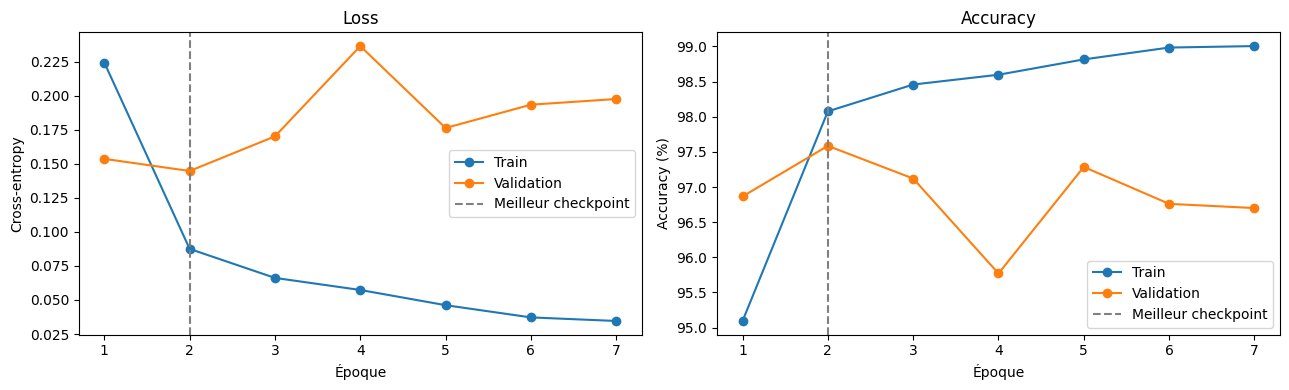

In [7]:
history = json.loads((ROOT/'reports/training_history.json').read_text())
epochs = [row['epoch']+1 for row in history]
fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].plot(epochs,[r['train_loss'] for r in history],marker='o',label='Train')
axes[0].plot(epochs,[r['val_loss'] for r in history],marker='o',label='Validation')
axes[0].axvline(2,color='gray',linestyle='--',label='Meilleur checkpoint')
axes[0].set(title='Loss',xlabel='Époque',ylabel='Cross-entropy'); axes[0].legend()
axes[1].plot(epochs,[100*r['train_acc'] for r in history],marker='o',label='Train')
axes[1].plot(epochs,[100*r['val_acc'] for r in history],marker='o',label='Validation')
axes[1].axvline(2,color='gray',linestyle='--',label='Meilleur checkpoint')
axes[1].set(title='Accuracy',xlabel='Époque',ylabel='Accuracy (%)'); axes[1].legend()
plt.tight_layout(); plt.show()

In [8]:
best = min(history, key=lambda row: row['val_loss'])
print('Meilleure époque :', best['epoch']+1)
print(f"Validation loss : {best['val_loss']:.4f}")
print(f"Validation accuracy : {best['val_acc']:.2%}")
print('Checkpoint :', next((ROOT/'models/checkpoints/resnet18-128').glob('best-*.ckpt'))) 

Meilleure époque : 2
Validation loss : 0.1446
Validation accuracy : 97.59%
Checkpoint : C:\Users\sail_\Documents\Codex\2026-08-08\you\balinese-script-transliteration-cnn\models\checkpoints\resnet18-128\best-epoch=01-val_loss=0.1446.ckpt


## Interprétation

La validation est optimale à l’époque 2. Ensuite, la loss du train continue à baisser tandis que la loss de validation remonte : c’est un début de surapprentissage. Le checkpointing empêche de retenir un modèle final moins généralisable.

## Conclusion

Le modèle entraîné est un ResNet18 de 11,2 millions de paramètres. Il atteint 97,59 % sur la meilleure validation. Le notebook 03 restaure ce checkpoint et réalise l’évaluation indépendante complète.